# Load asset returns
Monthly returns for Equity (SPY), Commodity (DBC), Bond (IEF) from Yahoo Finance, Cash from FRED `TB3MS`.

In [44]:
import io
import urllib.request

import pandas as pd
import yfinance as yf

START = "2006-06-01"

In [45]:
def fred(series, retries=4):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series}&cosd=1990-01-01"
    for i in range(retries):
        try:
            raw = urllib.request.urlopen(url, timeout=20).read().decode()
            break
        except Exception as e:  # FRED is occasionally slow; retry
            if i == retries - 1:
                raise
            print(f"retry {series}: {e}")
    df = pd.read_csv(io.StringIO(raw), index_col=0, parse_dates=True)
    s = pd.to_numeric(df.iloc[:, 0], errors="coerce").dropna()
    s.index = s.index.to_period("M")
    return s

In [ ]:
def load_assets():
    px = yf.download(["SPY", "IEF", "DBC"], start=START, auto_adjust=True, progress=False)["Close"]
    m = px.resample("ME").last().pct_change()
    m.index = m.index.to_period("M")
    m = m.rename(columns={"DBC": "Commodity", "IEF": "Bond", "SPY": "Equity"})
    m["Cash"] = fred("TB3MS") / 100 / 12
    return m[["Equity", "Commodity", "Cash", "Bond"]].dropna()

In [ ]:
assets = load_assets()
assets.tail()

In [ ]:
assets.describe()

## Example: using `fred()`
`fred(series_id)` returns a monthly `pd.Series` indexed by `Period[M]`. Find IDs at https://fred.stlouisfed.org.

In [ ]:
cpi = fred("CPIAUCSL")      # CPI, all urban consumers (index level)
cpi.tail()

In [ ]:
# transform: year-over-year inflation in %
cpi_yoy = cpi.pct_change(12) * 100
cpi_yoy.tail()

In [ ]:
# several series at once -> one DataFrame (aligned on the monthly index)
macro = pd.DataFrame({
    "INDPRO": fred("INDPRO"),     # industrial production
    "CPI": fred("CPIAUCSL"),      # CPI
    "TBill3M": fred("TB3MS"),     # 3-month T-bill rate, %
})
macro.tail()

In [ ]:
# quick plot of YoY inflation since 1990
cpi_yoy["1990":].plot(title="US CPI inflation, YoY %", figsize=(9, 3));

# Worked example: the Investment Clock step by step
Run the cells above first (imports, `fred`, `load_assets`). Each step below shows real numbers.
Settings: smooth over 3 months, direction = change over 3 months, signal lagged 2 months.

In [ ]:
SMOOTH, DIR_WIN, LAG = 3, 3, 2
import numpy as np

## Step 1 - Is growth rising? (industrial production)

In [ ]:
ip = fred("INDPRO")
ex = pd.DataFrame({"IP level": ip})
ex["1) YoY growth %"] = ip.pct_change(12) * 100                 # vs same month last year
ex["2) smoothed (3m avg)"] = ex["1) YoY growth %"].rolling(SMOOTH).mean()
ex["3) smoothed 3m ago"] = ex["2) smoothed (3m avg)"].shift(DIR_WIN)
ex["4) growth rising?"] = ex["2) smoothed (3m avg)"] > ex["3) smoothed 3m ago"]
ex.tail(8).round(2)

## Step 2 - Is inflation rising? (CPI, same recipe)

In [ ]:
cpi = fred("CPIAUCSL")
inf = pd.DataFrame({"CPI level": cpi})
inf["1) YoY inflation %"] = cpi.pct_change(12) * 100
inf["2) smoothed (3m avg)"] = inf["1) YoY inflation %"].rolling(SMOOTH).mean()
inf["3) smoothed 3m ago"] = inf["2) smoothed (3m avg)"].shift(DIR_WIN)
inf["4) inflation rising?"] = inf["2) smoothed (3m avg)"] > inf["3) smoothed 3m ago"]
inf.tail(8).round(2)

## Step 3 - Majority vote for growth (3 sources)

In [ ]:
def direction(level_or_growth):
    s = level_or_growth.rolling(SMOOTH).mean()
    return (s - s.shift(DIR_WIN)) > 0

votes = pd.DataFrame({
    "INDPRO": direction(fred("INDPRO").pct_change(12) * 100),
    "CFNAI":  direction(fred("CFNAI")),
    "UNRATE": direction(-fred("UNRATE")),      # sign flipped: falling unemployment = growth up
}).dropna()
votes["votes up"] = votes.sum(axis=1)
votes["growth rising? (>=2 of 3)"] = votes["votes up"] >= 2
votes.tail(8)

## Step 4 - Combine into a phase, then delay it by 2 months

In [ ]:
PHASES = {(True, False): "Recovery", (True, True): "Overheat",
          (False, True): "Stagflation", (False, False): "Reflation"}
BEST = {"Recovery": "Equity", "Overheat": "Commodity", "Stagflation": "Cash", "Reflation": "Bond"}

infl_up = direction(cpi.pct_change(12) * 100)
phase = pd.DataFrame({"growth_up": votes["growth rising? (>=2 of 3)"], "infl_up": infl_up}).dropna()
phase["phase"] = [PHASES[(bool(g), bool(i))] for g, i in zip(phase.growth_up, phase.infl_up)]
phase["clock says hold"] = phase["phase"].map(BEST)

signal = phase["phase"].copy()
signal.index = signal.index + LAG      # data for month t is only usable in month t+2
phase.tail(8)

## Step 5 - Real monthly returns, joined with the phase
(uses `assets` from `load_assets()`: SPY, DBC, IEF, T-bill, nominal)

In [ ]:
assets = load_assets()
infl_m = cpi.pct_change()                              # monthly inflation
real = (1 + assets).div(1 + infl_m, axis=0) - 1        # real return = (1+r)/(1+inflation) - 1
df = real.join(signal.rename("phase"), how="inner").dropna()
df.tail(8).round(4)

## Step 6 - Average return in each phase (geometric, per year)

In [ ]:
def geo_annual(x):
    return ((1 + x).prod() ** (12 / len(x)) - 1) * 100

ASSETS = ["Equity", "Commodity", "Cash", "Bond"]
table = df.groupby("phase")[ASSETS].apply(lambda g: g.apply(geo_annual)).round(1)
table["months"] = df.groupby("phase").size()
table["clock says"] = [BEST[p] for p in table.index]
table["actual best"] = table[ASSETS].idxmax(axis=1)
table

## Step 7 - Backtest: hold the clock's asset each month

In [ ]:
held = df["phase"].map(BEST)
clock = pd.Series([df.loc[i, a] for i, a in zip(df.index, held)], index=df.index)
curves = pd.DataFrame({"Clock": clock, "Equal weight": df[ASSETS].mean(axis=1), "Equity": df["Equity"]})
stats = pd.DataFrame({"real ann. return %": curves.apply(geo_annual),
                      "ann. vol %": curves.std() * np.sqrt(12) * 100})
stats["return / vol"] = stats["real ann. return %"] / stats["ann. vol %"]
display(stats.round(2))
(1 + curves).cumprod().plot(title="Real growth of $1", figsize=(9, 4));

## One month traced end to end
Pick any month and follow the numbers.

In [ ]:
m = pd.Period("2021-06", "M")      # change me
print("Month:", m)
print("IP YoY smoothed now      :", round(ex.loc[m, "2) smoothed (3m avg)"], 2))
print("IP YoY smoothed 3m ago   :", round(ex.loc[m, "3) smoothed 3m ago"], 2), "-> growth rising?", ex.loc[m, "4) growth rising?"])
print("CPI YoY smoothed now     :", round(inf.loc[m, "2) smoothed (3m avg)"], 2))
print("CPI YoY smoothed 3m ago  :", round(inf.loc[m, "3) smoothed 3m ago"], 2), "-> inflation rising?", inf.loc[m, "4) inflation rising?"])
print("Votes for growth up      :", int(votes.loc[m, "votes up"]), "of 3")
print("Phase                    :", phase.loc[m, "phase"], "-> clock says hold", phase.loc[m, "clock says hold"])
print("Tradable from            :", m + LAG, "(2-month delay)")

## Which data is running the phase call, right now?
The raw value of each growth source, its direction (rising/falling over 3 months), the vote, and the resulting phase -- for the most recent months.

In [25]:
SMOOTH, DIR_WIN = 3, 3

# raw growth series, each on its own natural scale
indpro_raw = fred("INDPRO").pct_change(12) * 100        # YoY industrial production growth, %
cfnai_raw  = fred("CFNAI")                               # already a "vs. trend" index (0 = trend)
unrate_raw = fred("UNRATE")                              # unemployment rate, %

pd.DataFrame({
    "INDPRO (YoY %)": indpro_raw,
    "CFNAI (vs. trend)": cfnai_raw,
    "UNRATE (%)": unrate_raw,
}).tail(8).round(2)

,INDPRO (YoY %),CFNAI (vs. trend),UNRATE (%)
observation_date,,,
2026-01,0.97,-0.07,4.3
2026-02,0.80,0.22,4.4
2026-03,0.69,-0.11,4.3
2026-04,1.43,0.13,4.3
2026-05,1.66,-0.10,4.3
2026-06,1.34,-0.01,4.2
2026-07,1.13,0.08,4.1
2026-08,1.42,-0.04,4.1


In [55]:
# smooth each one (3-month average), then test direction (higher than 3 months ago?)
def direction_table(raw, higher_is_growth=True):
    smoothed = raw.rolling(SMOOTH).mean()
    sign = 1 if higher_is_growth else -1
    rising = (sign * (smoothed - smoothed.shift(DIR_WIN))) > 0
    return smoothed, rising

indpro_sm, indpro_up = direction_table(indpro_raw, higher_is_growth=True)
cfnai_sm,  cfnai_up  = direction_table(cfnai_raw,  higher_is_growth=True)
unrate_sm, unrate_up = direction_table(unrate_raw, higher_is_growth=False)  # falling unemployment = growth up

votes = pd.DataFrame({
    "INDPRO smoothed": indpro_sm, "INDPRO says growth up?": indpro_up,
    "CFNAI smoothed": cfnai_sm,   "CFNAI says growth up?": cfnai_up,
    "UNRATE smoothed": unrate_sm, "UNRATE says growth up?": unrate_up,
}).dropna()
votes["votes for UP"] = votes[[c for c in votes.columns if "says" in c]].sum(axis=1)
votes["composite growth = UP?"] = votes["votes for UP"] >= 2
votes.observation_date = votes.index.to_timestamp()
votes_= votes.loc['2020-01':'2026-08']
votes_

C:\Users\xuexi\AppData\Local\Temp\ipykernel_30956\3813103343.py:19: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  votes.observation_date = votes.index.to_timestamp()


,INDPRO smoothed,INDPRO says growth up?,CFNAI smoothed,CFNAI says growth up?,UNRATE smoothed,UNRATE says growth up?,votes for UP,composite growth = UP?
observation_date,,,,,,,,
2020-01,-2.212387,False,-0.133333,True,3.600000,False,1,False
2020-02,-2.004261,True,-0.176667,True,3.566667,False,2,True
2020-03,-3.009552,False,-1.523333,False,3.833333,False,0,False
2020-04,-8.018853,False,-7.556667,False,7.566667,False,0,False
2020-05,-12.893692,False,-5.990000,False,10.800000,False,0,False
...,...,...,...,...,...,...,...,...
2026-04,0.972507,False,0.080000,True,4.333333,True,2,True
2026-05,1.259459,True,-0.026667,False,4.300000,True,2,True
2026-06,1.478650,True,0.006667,False,4.266667,True,2,True


In [58]:
# add inflation direction and the resulting phase, same recipe applied to CPI
import csv

from importlib_metadata import files
from matplotlib.pylab import save


cpi = fred("CPIAUCSL")
infl_sm = (cpi.pct_change(12) * 100).rolling(SMOOTH).mean()
infl_up = (infl_sm - infl_sm.shift(DIR_WIN)) > 0

PHASES = {(True, False): "Recovery", (True, True): "Overheat",
          (False, True): "Stagflation", (False, False): "Reflation"}

result = pd.DataFrame({
    "growth UP (2-of-3 vote)": votes["composite growth = UP?"],
    "inflation UP": infl_up,
}).dropna()
result["phase"] = [PHASES[(bool(g), bool(i))] for g, i in zip(result["growth UP (2-of-3 vote)"], result["inflation UP"])]
result.observation_date = result.index.to_timestamp()
results_ = result.loc['2020-01':'2026-09']
results_
infl_up



C:\Users\xuexi\AppData\Local\Temp\ipykernel_30956\2252734415.py:20: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  result.observation_date = result.index.to_timestamp()


observation_date
1990-01    False
1990-02    False
1990-03    False
1990-04    False
1990-05    False
           ...  
2026-04     True
2026-05     True
2026-06     True
2026-07     True
2026-08    False
Freq: M, Name: CPIAUCSL, Length: 439, dtype: bool

In [ ]:
votes_ = votes.loc['2020-01':'2025-01']
votes_.to_csv("../results/model_outputs/votes_2020_2025.csv", index_label="month")

result_ = result.loc['2020-01':'2025-01']
result_.to_csv("../results/model_outputs/result_2020_2025.csv", index_label="month")


## FRED-style plot: INDPRO, CFNAI, UNRATE, CPIAUCSL with recession shading
Four stacked panels, one per series, with grey vertical bands marking NBER recessions (`USREC`) -- the same style as FRED's own charts.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

usrec = fred("USREC")  # NBER recession indicator, 1 = recession, monthly

series = {
    "INDPRO":  ("Industrial Production", fred("INDPRO")),
    "CFNAI":   ("Chicago Fed National Activity Index", fred("CFNAI")),
    "UNRATE":  ("Unemployment Rate (%)", fred("UNRATE")),
    "CPIAUCSL":("CPI, All Urban Consumers (index level)", fred("CPIAUCSL")),
}

# recession shading: turn the 0/1 USREC series into a list of (start, end) spans
def recession_spans(usrec, start=None):
    r = usrec if start is None else usrec[usrec.index >= start]
    spans, in_rec, s = [], False, None
    for m, v in r.items():
        if v == 1 and not in_rec:
            in_rec, s = True, m
        elif v == 0 and in_rec:
            spans.append((s.to_timestamp(), (m - 1).to_timestamp("M")))
            in_rec = False
    if in_rec:
        spans.append((s.to_timestamp(), r.index[-1].to_timestamp("M")))
    return spans

START = "1960-01"
spans = recession_spans(usrec, START)

fig, axes = plt.subplots(4, 1, figsize=(12, 11), sharex=True)
for ax, (code_, (label, s)) in zip(axes, series.items()):
    s_plot = s[s.index >= START]
    ax.plot(s_plot.index.to_timestamp(), s_plot.values, color="#1f5fa8", linewidth=1)
    for a, b in spans:
        ax.axvspan(a, b, color="grey", alpha=0.3, linewidth=0)
    ax.set_title(f"{code_} — {label}", loc="left", fontsize=11)
    ax.margins(x=0)

axes[-1].xaxis.set_major_locator(mdates.YearLocator(5))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("Growth, activity, labor market and prices, with NBER recessions shaded", y=1.01)
plt.tight_layout()
plt.savefig("../results/plots/fred_style_indicators.png", dpi=130, bbox_inches="tight")
plt.show()

## Real-data version of Greetham's Chart 2 (growth vs. trend, inflation, and the four phases)
Chart 2 in the original report is a stylized sine wave. Here we plot the actual growth and inflation
series and shade the background by which of the four phases (Recovery / Overheat / Stagflation /
Reflation) each month falls into -- the same idea as Greetham's own Chart 6, using our own
composite-vote phase classification.

In [ ]:
PHASE_COLORS = {"Recovery": "#8fd694", "Overheat": "#e5867a", "Stagflation": "#e8c26a", "Reflation": "#8fb6e0"}
PHASE_ORDER = ["Reflation", "Recovery", "Overheat", "Stagflation"]  # clockwise order, matches Chart 2

# growth (vs. trend) = CFNAI, already centered on 0; inflation = smoothed YoY CPI, %
growth_vs_trend = fred("CFNAI").rolling(SMOOTH).mean()
infl_level = (fred("CPIAUCSL").pct_change(12) * 100).rolling(SMOOTH).mean()

chart_start = "1990-01"
g = growth_vs_trend[growth_vs_trend.index >= chart_start]
i = infl_level[infl_level.index >= chart_start]
def phase_spans(series):
    """contiguous (start, end, phase) spans from a phase series; NaN months and gaps stay blank"""
    s = series.dropna()
    out, cur, start, prev = [], None, None, None
    for t, v in s.items():
        if cur is None:
            cur, start = v, t
        elif v != cur or (t - prev).n != 1:      # new phase, or a missing month in between
            out.append((start, prev, cur)); cur, start = v, t
        prev = t
    if cur is not None:
        out.append((start, prev, cur))
    return out

HIDE_LATEST_MONTH = True   # the newest month is provisional (latest CFNAI/CPI are revised); set False to show it

ph = result["phase"].reindex(g.index)        # no ffill/bfill: months without data stay blank
if HIDE_LATEST_MONTH and ph.last_valid_index() is not None:
    ph = ph.copy()
    ph.loc[ph.last_valid_index()] = float("nan")

# turn the phase series into contiguous (start, end, phase) spans for shading
spans = phase_spans(ph)

fig, ax1 = plt.subplots(figsize=(13, 5.5))
for a, b, phase in spans:
    ax1.axvspan(a.to_timestamp(), (b + 1).to_timestamp(), color=PHASE_COLORS[phase], alpha=0.55, linewidth=0)

ax1.plot(g.index.to_timestamp(), g.values, color="black", linewidth=1.3, label="Growth vs. trend (CFNAI, smoothed)")
ax1.axhline(0, color="black", linewidth=0.6, linestyle=":")
ax1.set_ylabel("Growth vs. trend (CFNAI)")

ax2 = ax1.twinx()
ax2.plot(i.index.to_timestamp(), i.values, color="#b03060", linewidth=1.3, label="CPI YoY % (smoothed)")
ax2.set_ylabel("CPI YoY %, smoothed", color="#b03060")
ax2.tick_params(axis="y", labelcolor="#b03060")

handles = [plt.Line2D([0], [0], color="black", lw=1.3, label="Growth vs. trend (CFNAI)"),
           plt.Line2D([0], [0], color="#b03060", lw=1.3, label="CPI YoY % (smoothed)")]
legend_patches = [plt.Rectangle((0, 0), 1, 1, color=PHASE_COLORS[p], alpha=0.55, label=p) for p in PHASE_ORDER]
ax1.legend(handles=handles + legend_patches, loc="upper left", ncol=2, fontsize=9, framealpha=0.9)

ax1.set_title("Line: CFNAI (growth vs. trend) and CPI. Shading: phase from the 3-factor composite vote (INDPRO, CFNAI, UNRATE) + CPI direction")
ax1.margins(x=0)
plt.tight_layout()
plt.savefig("../results/plots/chart2_style_phases.png", dpi=130, bbox_inches="tight")
plt.show()

### Zoomed-in version (last 10 years) -- the full-history chart above is too fragmented to read
Our monthly phase signal flips every ~3 months on average (see the earlier episode-length analysis),
so over 36 years the shading looks like static rather than clean blocks. Zooming in shows the
actual phase structure clearly.

In [ ]:
zoom_start = "2016-01"
gz = growth_vs_trend[growth_vs_trend.index >= zoom_start]
iz = infl_level[infl_level.index >= zoom_start]
phz = ph[ph.index >= zoom_start]

spans_z = phase_spans(phz)

fig, ax1 = plt.subplots(figsize=(13, 5.5))
for a, b, phase in spans_z:
    ax1.axvspan(a.to_timestamp(), (b + 1).to_timestamp(), color=PHASE_COLORS[phase], alpha=0.55, linewidth=0)

ax1.plot(gz.index.to_timestamp(), gz.values, color="black", linewidth=1.5, label="Growth vs. trend (CFNAI)")
ax1.axhline(0, color="black", linewidth=0.6, linestyle=":")
ax1.set_ylabel("Growth vs. trend (CFNAI)")

ax2 = ax1.twinx()
ax2.plot(iz.index.to_timestamp(), iz.values, color="#b03060", linewidth=1.5, label="CPI YoY % (smoothed)")
ax2.set_ylabel("CPI YoY %, smoothed", color="#b03060")
ax2.tick_params(axis="y", labelcolor="#b03060")

handles = [plt.Line2D([0], [0], color="black", lw=1.5, label="Growth vs. trend (CFNAI)"),
           plt.Line2D([0], [0], color="#b03060", lw=1.5, label="CPI YoY % (smoothed)")]
legend_patches = [plt.Rectangle((0, 0), 1, 1, color=PHASE_COLORS[p], alpha=0.55, label=p) for p in PHASE_ORDER]
ax1.legend(handles=handles + legend_patches, loc="upper left", ncol=2, fontsize=9, framealpha=0.9)
ax1.set_title(f"Line: CFNAI and CPI. Shading: 3-factor composite phase, {zoom_start} onward", fontsize=10)
ax1.margins(x=0)
plt.tight_layout()
plt.savefig("../results/plots/chart2_style_phases_zoom.png", dpi=130, bbox_inches="tight")
plt.show()

### Zoomed further: 2025 onward only
Change `zoom_start` to `"2026-01"` to start from 2026 instead.

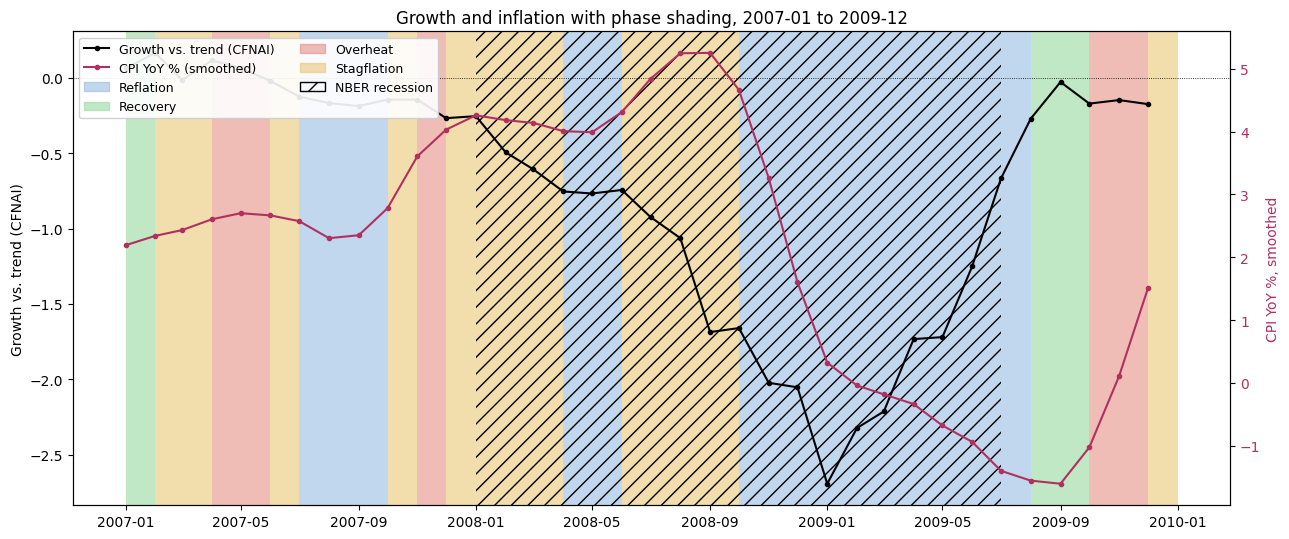

In [57]:
zoom_start = "2007-01"   # e.g. "2026-01"
zoom_end   = "2009-12"   # e.g. "2026-06" -- set to None for "through the latest available month"

def _clip(s):
    s = s[s.index >= zoom_start]
    return s[s.index <= zoom_end] if zoom_end else s

gz2 = _clip(growth_vs_trend)
iz2 = _clip(infl_level)
phz2 = _clip(ph)

spans_z2 = phase_spans(phz2)

# NBER recession spans, clipped to the same window, as a hatch overlay (doesn't hide the phase color underneath)
usrec_z = _clip(fred("USREC"))
rec_spans_z = []
in_rec, start = False, None
for t, v in usrec_z.items():
    if v == 1 and not in_rec:
        in_rec, start = True, t
    elif v == 0 and in_rec:
        rec_spans_z.append((start, t - 1)); in_rec = False
if in_rec:
    rec_spans_z.append((start, usrec_z.index[-1]))

fig, ax1 = plt.subplots(figsize=(13, 5.5))
for a, b, phase in spans_z2:
    ax1.axvspan(a.to_timestamp(), (b + 1).to_timestamp(), color=PHASE_COLORS[phase], alpha=0.55, linewidth=0)
for a, b in rec_spans_z:
    ax1.axvspan(a.to_timestamp(), (b + 1).to_timestamp(), facecolor="none", edgecolor="black",
                hatch="//", linewidth=0, zorder=2, label="_nolegend_")

ax1.plot(gz2.index.to_timestamp(), gz2.values, color="black", marker="o", markersize=3,
          linewidth=1.5, label="Growth vs. trend (CFNAI)")
ax1.axhline(0, color="black", linewidth=0.6, linestyle=":")
ax1.set_ylabel("Growth vs. trend (CFNAI)")

ax2 = ax1.twinx()
ax2.plot(iz2.index.to_timestamp(), iz2.values, color="#b03060", marker="o", markersize=3,
          linewidth=1.5, label="CPI YoY % (smoothed)")
ax2.set_ylabel("CPI YoY %, smoothed", color="#b03060")
ax2.tick_params(axis="y", labelcolor="#b03060")

handles = [plt.Line2D([0], [0], color="black", lw=1.5, marker="o", markersize=3, label="Growth vs. trend (CFNAI)"),
           plt.Line2D([0], [0], color="#b03060", lw=1.5, marker="o", markersize=3, label="CPI YoY % (smoothed)")]
legend_patches = [plt.Rectangle((0, 0), 1, 1, color=PHASE_COLORS[p], alpha=0.55, label=p) for p in PHASE_ORDER]
recession_patch = plt.Rectangle((0, 0), 1, 1, facecolor="none", edgecolor="black", hatch="//", label="NBER recession")
ax1.legend(handles=handles + legend_patches + [recession_patch], loc="upper left", ncol=2, fontsize=9, framealpha=0.9)
window_label = f"{zoom_start} to {zoom_end}" if zoom_end else f"{zoom_start} onward"
ax1.set_title(f"Line: CFNAI and CPI. Shading: 3-factor composite phase (INDPRO, CFNAI, UNRATE vote + CPI direction), {window_label}", fontsize=10)
ax1.margins(x=0.02)
plt.tight_layout()
plt.savefig(f"../results/plots/chart2_style_phases_{zoom_start}_to_{zoom_end or 'latest'}.png", dpi=130, bbox_inches="tight")
plt.show()